### 1. Introduction

"같은 것은 가까이, 다른 것은 멀리" 라는 아이디어에서 시작된 Contrastive learning은 Deep learning 분야에서 많이 각광 받아온 학습 방법이다.

Self-supervised learning 분야에서 주로 사용되며 2010년 말 빅테크기업에서 압도적인 연산력을 토대로 만들어낸 MoCo, SimCLR 같은 모델이 대표적인 예시이며, Multi-modal 학습 방법인 OpenAI의 CLIP의 C도 Contrastive이다.

Contrastive Loss는 여러가지가 있지만, 본 게시글에서는 SimCLR 논문에서 사용된 가장 많이 사용되는 Loss 중 하나인 InfoNCE 계열의 NT-Xent loss를 구현하고 코드 리뷰를 할 것이다.

Contrastive Loss에 대해 입문하거나 관심이 있다면 [Understanding Contrastive Representation Learning through Alignment and Uniformity on the Hypersphere](https://proceedings.mlr.press/v119/wang20k/wang20k.pdf)를 한번 읽어보는 것을 추천한다.

### 2. Preliminary

SimCLR은 2020년 구글에서 발표한 self-supervised learning 논문으로 한 sample에 두개의 augmented view를 만들어서 같은 이미지끼리는 큰 cosine similarity를 가지게 하고 서로 다른 이미지 샘플끼리는 낮은 cosine similarity를 가지도록 하는 방식으로 학습한다.

우선 수식부터 알아보자

$$
\begin{equation}
l(i, j)=-log\frac{exp(sim(z_i, z_j)/\tau)}{\sum^{2N}_{k=1} \mathbb{1}_{[k \neq i]}exp(sim(z_i, z_k)/\tau) }
\end{equation}
$$

위 식을 흐린눈 하고 보면 익숙한 수식이 보인다. 많은 블로거들이 외치듯 위 loss는 softmax의 형태를 하고 있다. 이 수식은 positive pair와 negative pair로 구분하도록 한다. 
<hr>
N은 batch size이다. 분모항의 sumation에서 2N이 나타난 이유는 모든 샘플에 있어서 2개의 augmented view를 생성하기 때문이다. 여기서 i와 j는 같은 sample의 서로 다른 augmented view이고 sim은 cosine similarity이다. 

즉 i, j는 같은 sample이므로 positive pair가 되고 분모는 i가 자기 자신을 제외한 positive, negative pair의 cosine similarity를 지수승하여 합한 값이다.

$\tau$는 분포를 좀 더 뾰족하거나 완만하게 만들어준다.

### implementation

[참고 코드](https://github.com/sthalles/SimCLR/blob/master/simclr.py)에서 class 내의 함수를 꺼내서 사용할 수 있도록 아주 약간 수정했으며 핵심 메커니즘은 그대로임을 미리 알린다.

In [1]:
import torch    
import torch.nn.functional as F

def NTXentLoss(features, batch_size, n_views, temperature, device):
    # classification 문제이기 때문에 labels을 생성함.
    labels = torch.cat([torch.arange(batch_size) for i in range(n_views)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    labels = labels.to(device)

    # cosine similarity를 global하게 계산함.
    features = F.normalize(features, dim=1) # 입력은 [B, D]
    similarity_matrix = torch.matmul(features, features.T)

    # discard the main diagonal from both: labels and similarities matrix 
    # diagonal 원소는 본인이기 때문에 k!=i를 지키기 위해 masking
    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(device)
    
    # view 함수는 tensor 형태의 데이터의 shape을 바꿔주는 함수 - Shared Data / Memory Efficiency
    labels = labels[~mask].view(labels.shape[0], -1) # ~mask은 torch에서 True인 원소들을 없애고 값을 반환하므로 2N x (2N-1)짜리 행렬이 나오게 됨
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)
    
    # 굳이 아래처럼 positives와 negatives를 일렬로 작업하는 이유는 cross entropy 계산 시 label을 항상 0번째 열로 고정할 수 있기 때문임.
    # select and combine multiple positives
    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)

    # select only the negatives the negatives
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)

    logits = torch.cat([positives, negatives], dim=1)
    labels = torch.zeros(logits.shape[0], dtype=torch.long).to(device)

    # temperature 계산
    logits = logits / temperature
    return logits, labels

In [2]:
BATCH_ZISE = N_VIEW = 2 # Batch가 2이고 augmentated view가 2개 있다고 가정했을 때

# labels 구성은 다음과 같다.
labels = torch.cat([torch.arange(BATCH_ZISE) for i in range(N_VIEW)], dim=0)
labels

tensor([0, 1, 0, 1])

In [3]:
# unsueeze는 추가하는 차원축의 인덱스를 지정할 수 있다.
print(labels.unsqueeze(0))
print(labels.unsqueeze(1))

tensor([[0, 1, 0, 1]])
tensor([[0],
        [1],
        [0],
        [1]])


In [4]:
labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
labels

tensor([[1., 0., 1., 0.],
        [0., 1., 0., 1.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.]])

In [5]:
# torch.eye는 대각 성분만 1이고 나머지는 0인 텐서를 만든다.
mask = torch.eye(labels.shape[0], dtype=torch.bool)
mask

tensor([[ True, False, False, False],
        [False,  True, False, False],
        [False, False,  True, False],
        [False, False, False,  True]])

In [6]:
# 마스킹을 하면 다음과 같이 True인 부분만 남기고 False인 부분은 없앤다. 이는 torch 특유의 연산이다.
m = torch.tensor([True, False])
l1 = torch.tensor([1,2])
l1[m]

tensor([1])

In [7]:
labels = labels[~mask].view(labels.shape[0], -1)
labels

tensor([[0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]])

### 4. Low Loss, High Loss, Collapse Loss
이제 구현한 Loss를 활용하여 언제 Loss가 높아지고 낮아지는지 그리고 붕괴는 어떻게 일어나는지 알아보자.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ── Low Loss ──────────────────────────────────────────────────────────────────
z1_low = torch.tensor([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])
z2_low = torch.tensor([[1.0, 0.1], [0.1, 1.0], [-1.0, 0.1], [0.1, -1.0]])  # z1이랑 거의 같은 방향

z = torch.cat([z1_low, z2_low], dim=0)
logits, labels = NTXentLoss(z, 4, 2, 0.1, 'cpu')
loss_low = F.cross_entropy(logits, labels).item()

print(f"Low  Loss: {loss_low:.4f}")

Low  Loss: 0.0003


In [9]:
# ── High Loss ─────────────────────────────────────────────────────────────────
z1_high = torch.tensor([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])
z2_high = torch.tensor([[-1.0, 0.0], [0.0, -1.0], [1.0, 0.0], [0.0, 1.0]])  # 정반대 방향

z = torch.cat([z1_high, z2_high], dim=0)
logits, labels = NTXentLoss(z, 4, 2, 0.1, 'cpu')
loss_high = F.cross_entropy(logits, labels).item()

print(f"High Loss: {loss_high:.4f}")

High Loss: 20.0002


Collapse란 model이 입력과 무관하게 상수의 값을 내뱉는 상황이다. Collapse가 일어나면 model의 representation이 저하된다. 따라서 InfoNCE는 큰 배치를 이용하여 분모를 키워 collapse penalty를 강하게 함으로써 collapse가 쉽게 일어나지 않도록 한다. 이것이 SimCLR이 대용량 배치(e.g. 4096)를 필요로 하는 이유이기도 하다.

In [10]:
# ── Collapse ─────────────────────────────────────────────────────────────────
z1_collapse = torch.tensor([[1.0, 0.0], [1.0, 0.0], [1.0, 0.0], [1.0, 0.0], ])
z2_collapse = torch.tensor([[1.0, 0.0], [1.0, 0.0], [1.0, 0.0], [1.0, 0.0], ])

z = torch.cat([z1_collapse, z2_collapse], dim=0)
logits, labels = NTXentLoss(z, 4, 2, 0.1, 'cpu')
loss_collapse = F.cross_entropy(logits, labels).item()

print(f"Collapse Loss: {loss_collapse:.4f}")

Collapse Loss: 1.9459


만능 클로드의 힘을 빌려 시각화를 하며 글을 마무리한다.

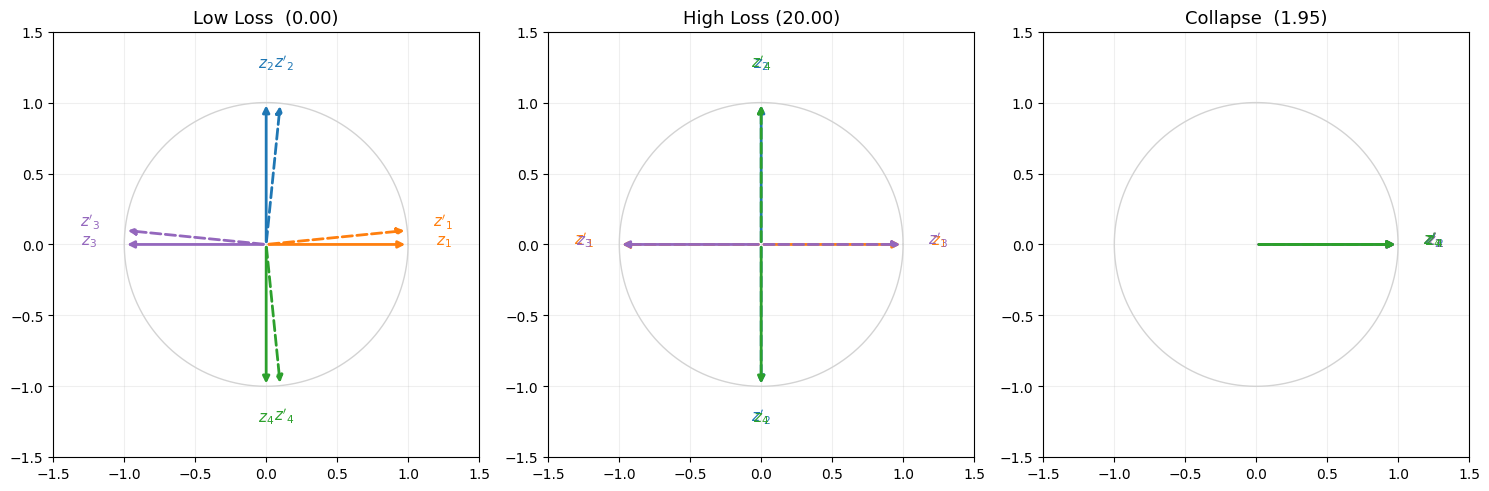

In [11]:

# ── 시각화 ────────────────────────────────────────────────────────────────────
COLORS = ['tab:orange', 'tab:blue', 'tab:purple', 'tab:green']
theta  = np.linspace(0, 2 * np.pi, 300)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

for ax, title, loss_val, z1, z2 in [
    (ax1, f"Low Loss  ({loss_low:.2f})",      loss_low,      z1_low,      z2_low),
    (ax2, f"High Loss ({loss_high:.2f})",     loss_high,     z1_high,     z2_high),
    (ax3, f"Collapse  ({loss_collapse:.2f})", loss_collapse, z1_collapse, z2_collapse),
]:
    ax.plot(np.cos(theta), np.sin(theta), 'lightgray', lw=1)
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.2)

    z1n = F.normalize(z1, dim=1).numpy()
    z2n = F.normalize(z2, dim=1).numpy()

    for i in range(4):
        c = COLORS[i]
        ax.annotate("", xy=z1n[i], xytext=(0,0),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
        ax.annotate("", xy=z2n[i], xytext=(0,0),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=2, linestyle='dashed'))
        ax.text(*(z1n[i] * 1.25), f"$z_{i+1}$",  color=c, ha='center', fontsize=11)
        ax.text(*(z2n[i] * 1.25), f"$z'_{i+1}$", color=c, ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("ntxent_circle.png")
plt.show()